# Banking Crisis Early Warning and Macro-Financial Risk Monitoring

## Project Overview

This project develops a historical one-year-ahead banking-crisis early-warning workflow using macro-financial data from African countries.

This project was originally completed as part of the GoMyCode Data Science Programme.

The analytical question is:

> Can macro-financial conditions observed in year *t* provide a useful warning signal for whether a banking crisis is recorded in year *t + 1*?

The project combines exploratory analysis, leakage-aware target design, time-aware model validation, class-imbalance-aware evaluation, and an interactive Streamlit application.

### Important scope

This is a historical portfolio analysis. It is not a current country forecast, stress test, regulatory assessment, investment recommendation, or policy decision tool.

### Notebook Structure

1. Imports and Setup
2. Load Data and Basic Exploration
3. Data Quality and Cleaning
4. Exploratory Data Analysis
5. One-Year-Ahead Target Construction
6. Temporal Train-Test Strategy
7. Preprocessing and Model Comparison
8. Final Historical Holdout Evaluation
9. Model Interpretation
10. Key Insights, Practical Implications, Limitations and Conclusion

## 1. Imports and Setup

The notebook uses the shared modelling functions in `src/modeling.py` so that notebook analysis and Streamlit inference follow the same data definitions and preprocessing rules.

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.modeling import (
    TARGET_COLUMN,
    YEAR_COLUMN,
    build_model_features,
    clean_source_data,
    compare_models,
    evaluate_holdout,
    feature_effects,
    fit_selected_model,
    load_raw_data,
    prepare_early_warning_frame,
    select_model_name,
    temporal_holdout_split,
)

IMAGES_DIR = ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

## 2. Load Data and Basic Exploration

The code first looks for a local CSV under `data/`. If no local copy is present, it attempts to use the public mirror documented in `data/README.md`.

The commonly circulated African Crises dataset contains country-year observations covering banking, systemic, currency, inflation, sovereign-debt, exchange-rate and inflation indicators.

In [3]:
raw = load_raw_data()

print(f"Raw shape: {raw.shape}")
print(f"Countries: {raw['country'].nunique()}")
print(f"Year range: {raw['year'].min()} to {raw['year'].max()}")
print(f"Duplicate rows: {raw.duplicated().sum()}")
print(f"Total missing values: {int(raw.isna().sum().sum())}")

display(raw.head())

Raw shape: (1059, 14)
Countries: 13
Year range: 1860 to 2014
Duplicate rows: 0
Total missing values: 0


,country_number,country_code,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


### Data Dictionary

| Variable | Meaning |
| --- | --- |
| `country_number` | Country identifier in the source data |
| `country_code` | Three-letter country code |
| `country` | Country name |
| `year` | Observation year |
| `systemic_crisis` | Systemic-crisis indicator |
| `exch_usd` | Exchange rate against the US dollar |
| `domestic_debt_in_default` | Domestic sovereign-debt default indicator |
| `sovereign_external_debt_default` | External sovereign-debt default indicator |
| `gdp_weighted_default` | Debt in default relative to GDP |
| `inflation_annual_cpi` | Annual CPI inflation rate |
| `independence` | Independence indicator in the source data |
| `currency_crises` | Currency-crisis indicator |
| `inflation_crises` | Inflation-crisis indicator |
| `banking_crisis` | Banking-crisis label |

The source documentation defines `currency_crises` as binary. The dataset contains a small number of observations coded as `2`, so these are excluded rather than assigned an unsupported interpretation.

## 3. Data Quality and Cleaning

The target is kept in its original semantic form until the modelling frame is created. `crisis` is later mapped to `1` and `no_crisis` to `0`, which keeps the positive class intuitive for early-warning evaluation.

In [4]:
print("Banking-crisis distribution in the raw data:")
display(raw["banking_crisis"].value_counts(dropna=False).rename("count").to_frame())

print("Currency-crisis source codes:")
display(raw["currency_crises"].value_counts(dropna=False).sort_index().rename("count").to_frame())

clean = clean_source_data(raw)
print(f"Shape after transparent source-data checks: {clean.shape}")
print(f"Rows excluded because currency_crises was not binary: {len(raw) - len(clean)}")

Banking-crisis distribution in the raw data:


,count
banking_crisis,
no_crisis,965
crisis,94


Currency-crisis source codes:


,count
currency_crises,
0,923
1,132
2,4


Shape after transparent source-data checks: (1055, 14)
Rows excluded because currency_crises was not binary: 4


## 4. Exploratory Data Analysis

The exploratory analysis focuses on questions relevant to the modelling problem:

- How rare are banking-crisis years?
- How does crisis frequency vary across countries?
- How are crisis observations distributed over time?
- How extreme are exchange-rate and inflation values?

The analysis avoids correlations based on arbitrary label-encoded country names.

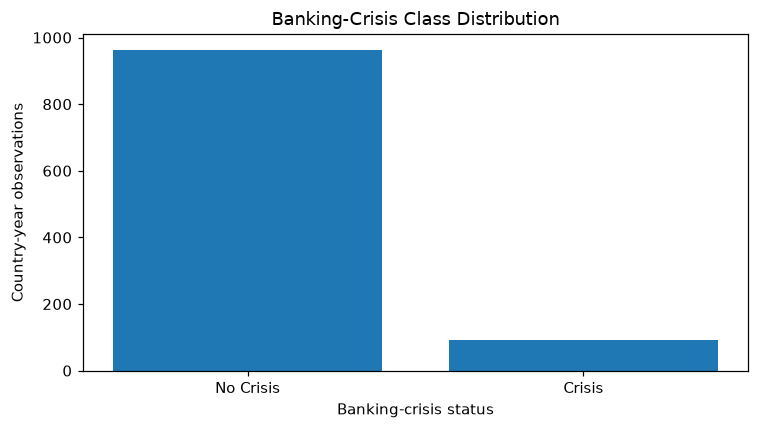

,country,observations,crisis_years,crisis_rate
2,Central African Republic,58,19,0.327586
8,Nigeria,60,11,0.183333
12,Zimbabwe,90,15,0.166667
5,Kenya,67,8,0.119403
1,Angola,75,6,0.080000
3,Egypt,155,11,0.070968
10,Tunisia,74,5,0.067568
4,Ivory Coast,63,4,0.063492
11,Zambia,72,4,0.055556
0,Algeria,85,4,0.047059


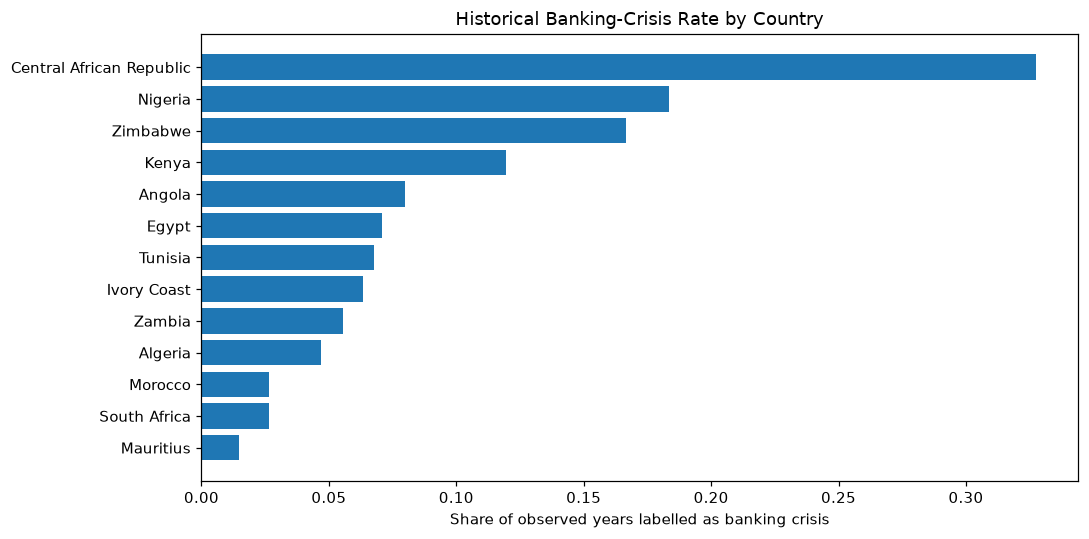

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = clean["banking_crisis"].value_counts().reindex(["no_crisis", "crisis"])
ax.bar(["No Crisis", "Crisis"], counts.values)
ax.set_title("Banking-Crisis Class Distribution")
ax.set_xlabel("Banking-crisis status")
ax.set_ylabel("Country-year observations")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "banking_crisis_distribution.png", bbox_inches="tight")
plt.show()

country_rates = (
    clean.assign(crisis=clean["banking_crisis"].eq("crisis").astype(int))
    .groupby("country", as_index=False)
    .agg(observations=("crisis", "size"), crisis_years=("crisis", "sum"), crisis_rate=("crisis", "mean"))
    .sort_values("crisis_rate", ascending=False)
)
display(country_rates)

fig, ax = plt.subplots(figsize=(10, 5))
plot_rates = country_rates.sort_values("crisis_rate")
ax.barh(plot_rates["country"], plot_rates["crisis_rate"])
ax.set_title("Historical Banking-Crisis Rate by Country")
ax.set_xlabel("Share of observed years labelled as banking crisis")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "banking_crisis_rate_by_country.png", bbox_inches="tight")
plt.show()


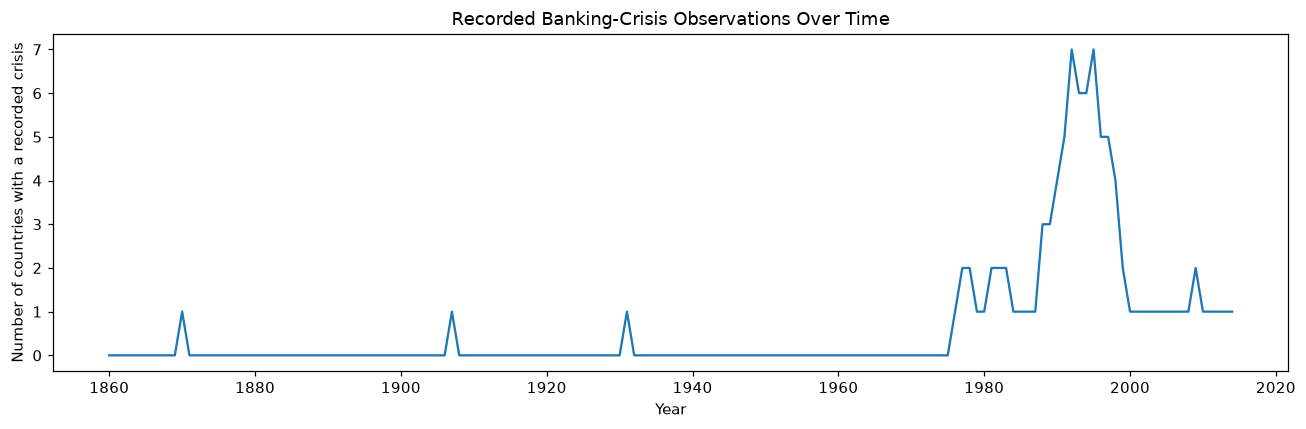

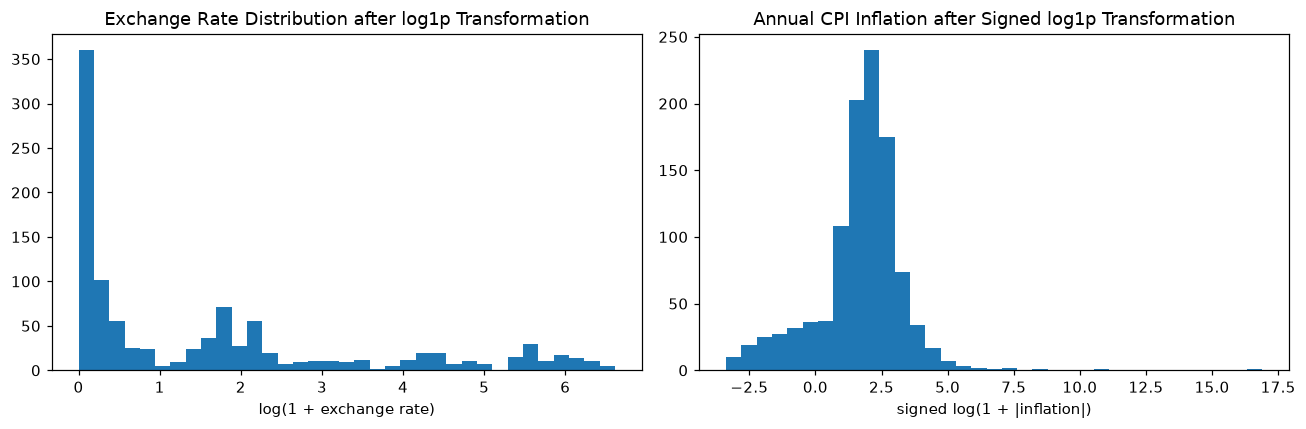

In [6]:
crises_over_time = (
    clean.assign(crisis=clean["banking_crisis"].eq("crisis").astype(int))
    .groupby("year", as_index=False)["crisis"]
    .sum()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(crises_over_time["year"], crises_over_time["crisis"])
ax.set_title("Recorded Banking-Crisis Observations Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Number of countries with a recorded crisis")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "banking_crises_over_time.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log1p(clean["exch_usd"].clip(lower=0)), bins=35)
axes[0].set_title("Exchange Rate Distribution after log1p Transformation")
axes[0].set_xlabel("log(1 + exchange rate)")

signed_log_inflation = np.sign(clean["inflation_annual_cpi"]) * np.log1p(np.abs(clean["inflation_annual_cpi"]))
axes[1].hist(signed_log_inflation, bins=35)
axes[1].set_title("Annual CPI Inflation after Signed log1p Transformation")
axes[1].set_xlabel("signed log(1 + |inflation|)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "macro_financial_transformed_distributions.png", bbox_inches="tight")
plt.show()


## 5. One-Year-Ahead Target Construction

A same-year classification model can make the task easier in a way that is not appropriate for an early-warning interpretation, especially when contemporaneous crisis variables are included as predictors.

This project therefore reframes the task:

```text
macro-financial indicators in year t
        ↓
banking-crisis status in year t + 1
```

For each country, the next observation must be exactly one calendar year later. Rows followed by a gap are not used for the one-year-ahead target.

In [7]:
early_warning = prepare_early_warning_frame(raw)

print(f"Early-warning modelling rows: {len(early_warning):,}")
print(f"Target-year range: {early_warning[YEAR_COLUMN].min()} to {early_warning[YEAR_COLUMN].max()}")
print(f"One-year-ahead crisis observations: {int(early_warning[TARGET_COLUMN].sum()):,}")
print(f"One-year-ahead crisis rate: {early_warning[TARGET_COLUMN].mean():.2%}")

display(
    early_warning[["country", "year", YEAR_COLUMN, TARGET_COLUMN]].head(10)
)

Early-warning modelling rows: 1,032
Target-year range: 1861 to 2014
One-year-ahead crisis observations: 90
One-year-ahead crisis rate: 8.72%


,country,year,target_year,banking_crisis_next_year
0,Algeria,1870,1871,0
1,Algeria,1871,1872,0
2,Algeria,1872,1873,0
3,Algeria,1873,1874,0
4,Algeria,1874,1875,0
5,Algeria,1875,1876,0
6,Algeria,1876,1877,0
7,Algeria,1877,1878,0
8,Algeria,1878,1879,0
9,Algeria,1879,1880,0


## 6. Temporal Train-Test Strategy

Because the project is framed as early warning, the latest period is held out for final historical evaluation rather than randomly mixing earlier and later years.

Within the training period, model comparison uses expanding-year validation. Each validation block occurs after its corresponding training block.

This does not recreate a full production backtesting framework, but it is more aligned with forecasting than a random train-test split.

In [8]:
train_frame, test_frame, cutoff_year = temporal_holdout_split(early_warning)

print(f"Historical training observations: {len(train_frame):,}")
print(f"Later-period holdout observations: {len(test_frame):,}")
print(f"Holdout starts at target year: {cutoff_year}")
print()
print("Training target distribution:")
print(train_frame[TARGET_COLUMN].value_counts().sort_index())
print()
print("Holdout target distribution:")
print(test_frame[TARGET_COLUMN].value_counts().sort_index())

Historical training observations: 645
Later-period holdout observations: 387
Holdout starts at target year: 1984

Training target distribution:
banking_crisis_next_year
0    630
1     15
Name: count, dtype: int64

Holdout target distribution:
banking_crisis_next_year
0    312
1     75
Name: count, dtype: int64


## 7. Preprocessing and Model Comparison

Preprocessing is fitted inside each training fold.

The shared preprocessing workflow uses:

- one-hot encoding for country and the currency-crisis source code;
- median imputation and standard scaling for transformed continuous features;
- mode imputation for binary indicators;
- log-based transformations for exchange-rate and inflation variables to reduce the influence of extreme historical values.

The following models are compared:

- Dummy prior baseline;
- Logistic Regression;
- Decision Tree;
- Random Forest;
- Support Vector Classifier.

ROC-AUC is the primary ranking metric. PR-AUC, balanced accuracy, precision, recall and F1 are also reviewed because crisis years are uncommon.

,model,folds,mean_roc_auc,std_roc_auc,mean_pr_auc,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1
0,Random Forest,2,0.7904,0.1331,0.1197,0.5000,0.0000,0.0000,0.0000
1,SVC,2,0.5911,0.2089,0.0501,0.4957,0.0588,0.0769,0.0667
2,Dummy Prior,2,0.5000,0.0000,0.0326,0.5000,0.0000,0.0000,0.0000
3,Decision Tree,2,0.4941,0.0059,0.0326,0.4941,0.0000,0.0000,0.0000
4,Logistic Regression,2,0.3474,0.0644,0.0364,0.4641,0.0526,0.0769,0.0625


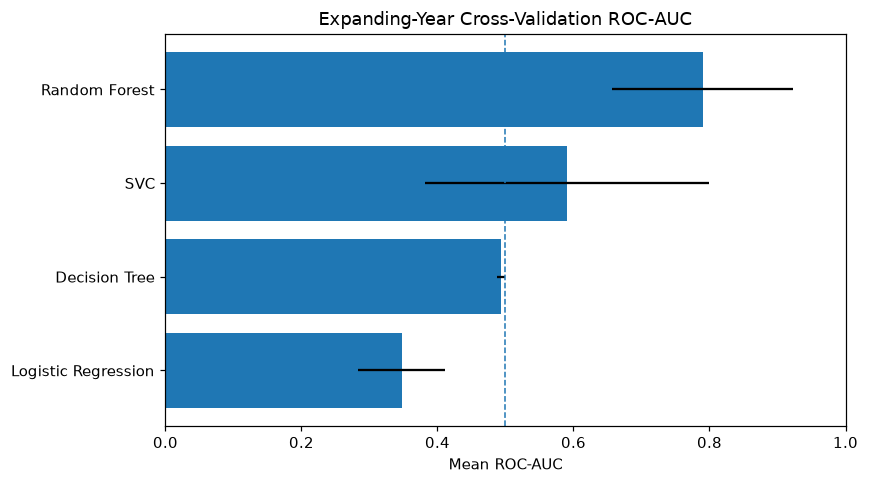

In [9]:
comparison = compare_models(train_frame, n_splits=5, include_dummy=True)

columns_to_show = [
    "model",
    "folds",
    "mean_roc_auc",
    "std_roc_auc",
    "mean_pr_auc",
    "mean_balanced_accuracy",
    "mean_precision",
    "mean_recall",
    "mean_f1",
]
display(comparison[columns_to_show].round(4))

plot_data = comparison[comparison["model"] != "Dummy Prior"].sort_values("mean_roc_auc")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_data["model"], plot_data["mean_roc_auc"], xerr=plot_data["std_roc_auc"])
ax.axvline(0.5, linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_title("Expanding-Year Cross-Validation ROC-AUC")
ax.set_xlabel("Mean ROC-AUC")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

### Model Selection Rule

The strongest validation ROC-AUC is identified first. Logistic Regression is retained when its mean ROC-AUC is within 0.02 of the strongest non-dummy candidate because interpretability and transparency are useful properties in an early-warning setting. Otherwise, the stronger candidate is retained.

The later-period holdout is not used to choose the model.

In [10]:
selected_name = select_model_name(comparison, simplicity_margin=0.02)
final_model = fit_selected_model(train_frame, selected_name)
holdout_metrics = evaluate_holdout(final_model, test_frame)

print(f"Selected model: {selected_name}")
print(f"Holdout cutoff target year: {cutoff_year}")
print()
for key in ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
    print(f"{key.replace('_', ' ').title():<20}: {holdout_metrics[key]:.4f}")
print()
print(
    f"Confusion matrix counts: TN={holdout_metrics['tn']}, FP={holdout_metrics['fp']}, "
    f"FN={holdout_metrics['fn']}, TP={holdout_metrics['tp']}"
)

Selected model: Random Forest
Holdout cutoff target year: 1984

Accuracy            : 0.8165
Balanced Accuracy   : 0.6229
Precision           : 0.5476
Recall              : 0.3067
F1                  : 0.3932
Roc Auc             : 0.7759
Pr Auc              : 0.4546

Confusion matrix counts: TN=293, FP=19, FN=52, TP=23


## 8. Final Historical Holdout Evaluation

The final model is evaluated once on the later historical period. Accuracy is reported for completeness, but ROC-AUC, PR-AUC, recall, F1 and the confusion matrix are more informative for this imbalanced early-warning problem.

                     precision    recall  f1-score   support

No Crisis Next Year       0.85      0.94      0.89       312
   Crisis Next Year       0.55      0.31      0.39        75

           accuracy                           0.82       387
          macro avg       0.70      0.62      0.64       387
       weighted avg       0.79      0.82      0.80       387



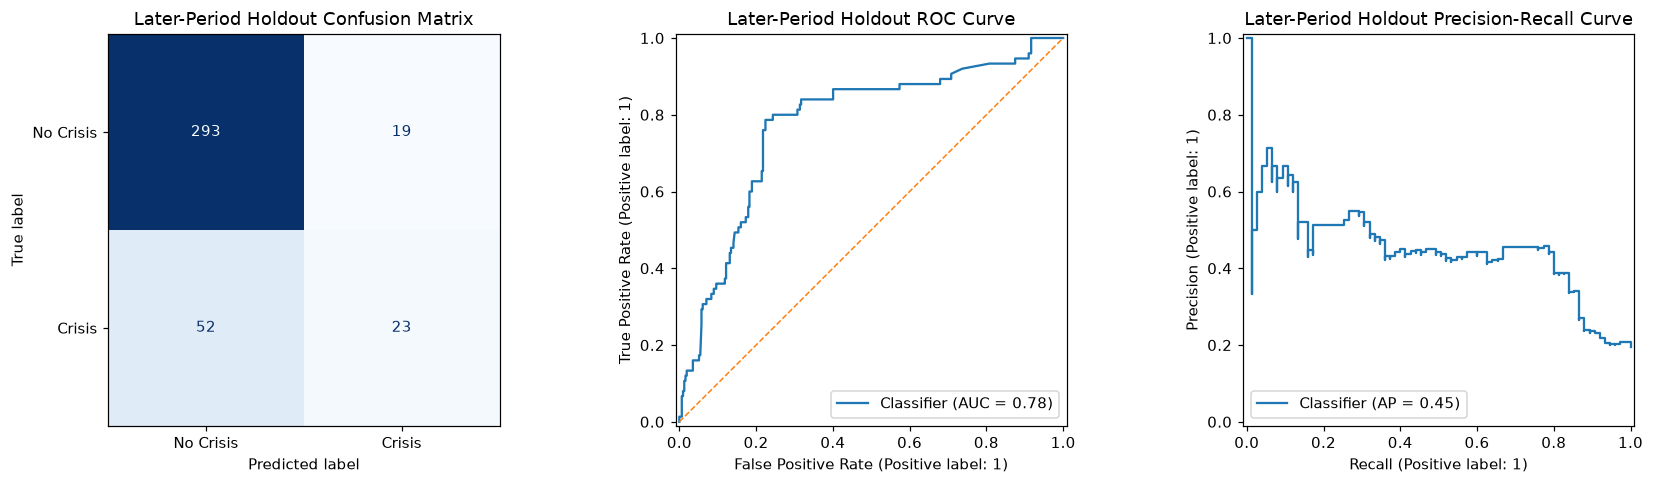

In [11]:
X_test = build_model_features(test_frame)
y_test = test_frame[TARGET_COLUMN].astype(int)
y_pred = final_model.predict(X_test)
y_score = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Crisis Next Year", "Crisis Next Year"], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Crisis", "Crisis"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Later-Period Holdout Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[1].set_title("Later-Period Holdout ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=axes[2])
axes[2].set_title("Later-Period Holdout Precision-Recall Curve")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "holdout_evaluation.png", bbox_inches="tight")
plt.show()

## 9. Model Interpretation

Where the selected estimator exposes coefficients or feature importances, the strongest fitted associations are displayed below.

These values describe predictive associations in the fitted historical model. They should not be interpreted as causal effects of macro-financial variables on banking crises.

,feature,value,kind,abs_value
0,continuous__inflation_signed_log1p,0.317245,importance,0.317245
1,continuous__exch_usd_log1p,0.185254,importance,0.185254
2,binary__systemic_crisis,0.156372,importance,0.156372
3,categorical__country_Central African Republic,0.104140,importance,0.104140
4,binary__independence,0.076773,importance,0.076773
5,categorical__country_Egypt,0.037972,importance,0.037972
6,categorical__country_South Africa,0.019439,importance,0.019439
7,categorical__country_Morocco,0.014134,importance,0.014134
8,categorical__country_Algeria,0.013662,importance,0.013662
9,binary__inflation_crises,0.012211,importance,0.012211


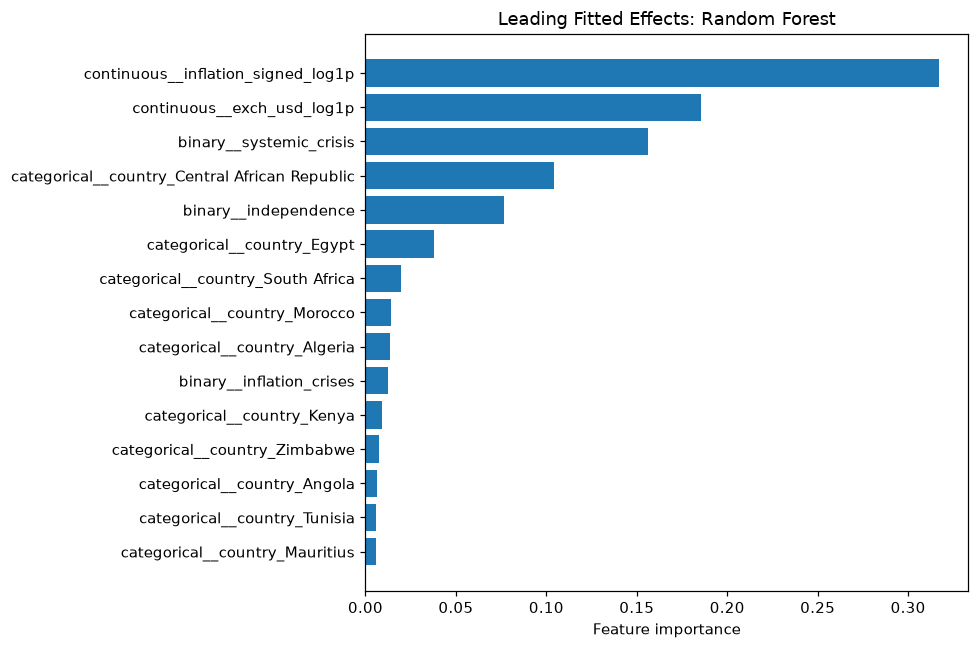

In [12]:
effects = feature_effects(final_model)

if effects.empty:
    print(f"{selected_name} does not expose simple global coefficients or feature importances in this workflow.")
else:
    display(effects.head(20))
    top_effects = effects.head(15).sort_values("value")
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top_effects["feature"], top_effects["value"])
    label = "Coefficient" if top_effects["kind"].iloc[0] == "coefficient" else "Feature importance"
    ax.set_xlabel(label)
    ax.set_title(f"Leading Fitted Effects: {selected_name}")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "model_interpretation.png", bbox_inches="tight")
    plt.show()

## 10. Key Insights, Practical Implications, Limitations and Conclusion

### Key Insights and Takeaways

- Banking-crisis years are uncommon relative to no-crisis years, so class-imbalance-aware evaluation is essential.
- The dataset spans more than a century of economic and institutional change, which makes simple random splitting unsuitable for an early-warning interpretation.
- The modelling task uses information from year *t* to predict year *t + 1*, reducing the risk of treating contemporaneous crisis conditions as advance warning signals.
- Exchange-rate and inflation variables contain extreme historical values, so log-based transformations provide a more stable numerical representation.
- Country identity can capture persistent structural differences, but this also limits claims about generalisation to countries outside the source data.

### Practical / Real-World Implications

A historical early-warning score could potentially provide one additional signal for macro-financial analysts when combined with richer banking-sector, market, supervisory and institutional evidence.

The output should not be used to automatically declare that a country will or will not experience a banking crisis. A real monitoring system would require current data, broader indicators, calibration, policy-relevant threshold design, external validation, governance and expert review.

### Recommended Real-World Next Steps

Future work could incorporate credit growth, credit-to-GDP gaps, bank capital and liquidity measures, non-performing loans, asset prices, interest-rate spreads, reserve adequacy, current-account indicators, market volatility and higher-frequency information. Rolling out-of-time validation and probability calibration would also be important before considering operational use.

### Limitations

- The source covers only 13 African countries.
- Crisis events are relatively rare.
- The target is next-year crisis status rather than first-onset only, so part of the signal may reflect persistence across multi-year crisis episodes.
- The data span different monetary regimes, institutional structures and financial-system eras.
- Annual frequency can miss rapidly developing stress.
- The available predictors are much narrower than a modern macroprudential surveillance dataset.
- Historical predictive associations are not evidence of causality.
- The Streamlit output is a portfolio demonstration rather than a live financial-stability assessment.

In [13]:
metric_text = (
    f"The selected model is **{selected_name}**. On the later-period holdout beginning in "
    f"**{cutoff_year}**, it achieved ROC-AUC **{holdout_metrics['roc_auc']:.3f}**, "
    f"PR-AUC **{holdout_metrics['pr_auc']:.3f}**, recall **{holdout_metrics['recall']:.3f}**, "
    f"and F1 **{holdout_metrics['f1']:.3f}**."
)

if holdout_metrics["roc_auc"] < 0.60:
    strength = (
        "The later-period discrimination is weak, so the model should be treated as an analytical "
        "workflow demonstration rather than a dependable early-warning classifier."
    )
elif holdout_metrics["roc_auc"] < 0.75:
    strength = (
        "The later-period discrimination is moderate. The model may be useful for exploratory "
        "prioritisation, but substantial additional validation would be required before operational use."
    )
else:
    strength = (
        "The later-period discrimination is comparatively strong within this historical sample, but "
        "the dataset limitations still prevent treating the result as a modern operational crisis forecast."
    )

display(Markdown(f"""
### Summary of Results

{metric_text}

{strength}

### Conclusion

This project demonstrates how a banking-crisis classification exercise can be structured as a more defensible one-year-ahead early-warning problem. The analysis combines historical macro-financial data, time-aware validation, appropriate classification metrics, explicit uncertainty, and an interactive application.

The main professional lesson is that early-warning modelling depends not only on algorithm choice, but also on target timing, leakage control, temporal validation, rare-event evaluation, data coverage and the intended decision context. The current model should therefore be viewed as a historical decision-support demonstration. A stronger real-world system would require richer and more current macro-financial data, rolling validation, calibration, monitoring and expert oversight.
"""))


### Summary of Results

The selected model is **Random Forest**. On the later-period holdout beginning in **1984**, it achieved ROC-AUC **0.776**, PR-AUC **0.455**, recall **0.307**, and F1 **0.393**.

The later-period discrimination is comparatively strong within this historical sample, but the dataset limitations still prevent treating the result as a modern operational crisis forecast.

### Conclusion

This project demonstrates how a banking-crisis classification exercise can be structured as a more defensible one-year-ahead early-warning problem. The analysis combines historical macro-financial data, time-aware validation, appropriate classification metrics, explicit uncertainty, and an interactive application.

The main professional lesson is that early-warning modelling depends not only on algorithm choice, but also on target timing, leakage control, temporal validation, rare-event evaluation, data coverage and the intended decision context. The current model should therefore be viewed as a historical decision-support demonstration. A stronger real-world system would require richer and more current macro-financial data, rolling validation, calibration, monitoring and expert oversight.


## Deployment Preparation

The Streamlit application at the repository root uses the same reusable feature engineering and model-selection functions as this notebook.

Run locally with:

```bash
py -m streamlit run app.py
```

See the repository README for deployment instructions and the live-demo placeholder.